In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.linear_model    import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics         import (accuracy_score, confusion_matrix,classification_report)
from sklearn.preprocessing   import StandardScaler

# (i)  READ DATASET INTO DATAFRAME
df = pd.read_csv('disease_risk.csv ')
print("Dataset Loaded\n",df.head(5))
print(df.head(5).to_string(index=False))
print(f"\n  Shape   : {df.shape}")
print(f"  Columns : {list(df.columns)}")
print("\n  Target Value Counts:")
print(df['disease_risk'].value_counts().rename({0:'0 = No Risk', 1:'1 = At Risk'}))
print("\n  Statistical Summary:")
print(df.describe().round(2))

Dataset Loaded
    age   bmi  blood_pressure  sugar_level  cholesterol  smoking  exercise_hrs  \
0   58  31.2              98          152          166        1           0.9   
1   71  33.3             171          178          235        1           6.3   
2   48  37.4             137          134          275        0           7.4   
3   34  31.7             134          155          193        1           8.5   
4   62  24.5             169          140          174        0           1.2   

   family_history  disease_risk  
0               1             1  
1               0             1  
2               1             1  
3               1             1  
4               0             0  
 age  bmi  blood_pressure  sugar_level  cholesterol  smoking  exercise_hrs  family_history  disease_risk
  58 31.2              98          152          166        1           0.9               1             1
  71 33.3             171          178          235        1           6.3         

In [7]:
# (ii)  SPLIT DATASET — 
features = ['age', 'bmi', 'blood_pressure', 'sugar_level','cholesterol', 'smoking', 'exercise_hrs', 'family_history']

X = df[features]
y = df['disease_risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42)

print(" Train-Test Split  (70:30)")
print(f"  Training samples : {len(X_train)}")
print(f"  Testing  samples : {len(X_test)}")

# Scale features (important for Logistic Regression)
scaler   = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

 Train-Test Split  (70:30)
  Training samples : 140
  Testing  samples : 60


In [11]:
# (iii)  TRAIN LOGISTIC REGRESSION MODEL
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_s, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [12]:
# Predictions on test set
y_pred      = model.predict(X_test_s)
y_pred_prob = model.predict_proba(X_test_s)[:, 1]   # probability of class 1

In [14]:
# (iv)  COEFFICIENTS and INTERCEPT


print("Model Coefficients and Intercept")

print(f"\n  {'Feature':<20} {'Coefficient':>14}")
for feat, coef in zip(features, model.coef_[0]):
    direction = " increases risk" if coef > 0 else " decreases risk"
    print(f"  {feat:<20} {coef:>10.4f}    {direction}")
print(f"\n  {'Intercept(C)':<20} {model.intercept_[0]:>14.4f}")

print("""
     How to read:
     Positive coefficient → feature INCREASES disease risk
     Negative coefficient → feature DECREASES disease risk
     Larger absolute value → stronger influence
""")

Model Coefficients and Intercept

  Feature                 Coefficient
  age                      1.2314     increases risk
  bmi                      0.8517     increases risk
  blood_pressure           2.0686     increases risk
  sugar_level              1.2390     increases risk
  cholesterol              1.3764     increases risk
  smoking                  1.3510     increases risk
  exercise_hrs            -1.1102     decreases risk
  family_history           2.3603     increases risk

  Intercept(C)                -0.0917

     How to read:
     Positive coefficient → feature INCREASES disease risk
     Negative coefficient → feature DECREASES disease risk
     Larger absolute value → stronger influence



In [17]:
# (v)  EVALUATION — Accuracy + Confusion Matrix

accuracy = accuracy_score(y_test, y_pred)
cm       = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

print(" Model Evaluation")


print(f"\n  Accuracy : {accuracy * 100:.2f}%")

print(f"""
  Confusion Matrix:
  
                Predicted                  
            No Risk    At Risk           
        
   Actual                              
   No Risk    TN={TN:>3}    FP={FP:>3}         
   At Risk    FN={FN:>3}    TP={TP:>3}         
        
""")

print(f"  TP (True  Positive) = {TP}  → Correctly predicted AT RISK")
print(f"  TN (True  Negative) = {TN}  → Correctly predicted NO RISK")
print(f"  FP (False Positive) = {FP}  → Wrongly predicted AT RISK")
print(f"  FN (False Negative) = {FN}  → Wrongly predicted NO RISK")

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\n  Precision : {precision:.4f}  (of all predicted At Risk, how many truly are)")
print(f"  Recall    : {recall:.4f}  (of all actual At Risk, how many we caught)")
print(f"  F1 Score  : {f1:.4f}  (balance between precision and recall)")

print("\n  Full Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=['No Risk (0)', 'At Risk (1)']))

 Model Evaluation

  Accuracy : 86.67%

  Confusion Matrix:

                Predicted                  
            No Risk    At Risk           

   Actual                              
   No Risk    TN= 23    FP=  2         
   At Risk    FN=  6    TP= 29         


  TP (True  Positive) = 29  → Correctly predicted AT RISK
  TN (True  Negative) = 23  → Correctly predicted NO RISK
  FP (False Positive) = 2  → Wrongly predicted AT RISK
  FN (False Negative) = 6  → Wrongly predicted NO RISK

  Precision : 0.9355  (of all predicted At Risk, how many truly are)
  Recall    : 0.8286  (of all actual At Risk, how many we caught)
  F1 Score  : 0.8788  (balance between precision and recall)

  Full Classification Report:
              precision    recall  f1-score   support

 No Risk (0)       0.79      0.92      0.85        25
 At Risk (1)       0.94      0.83      0.88        35

    accuracy                           0.87        60
   macro avg       0.86      0.87      0.87        60
weig

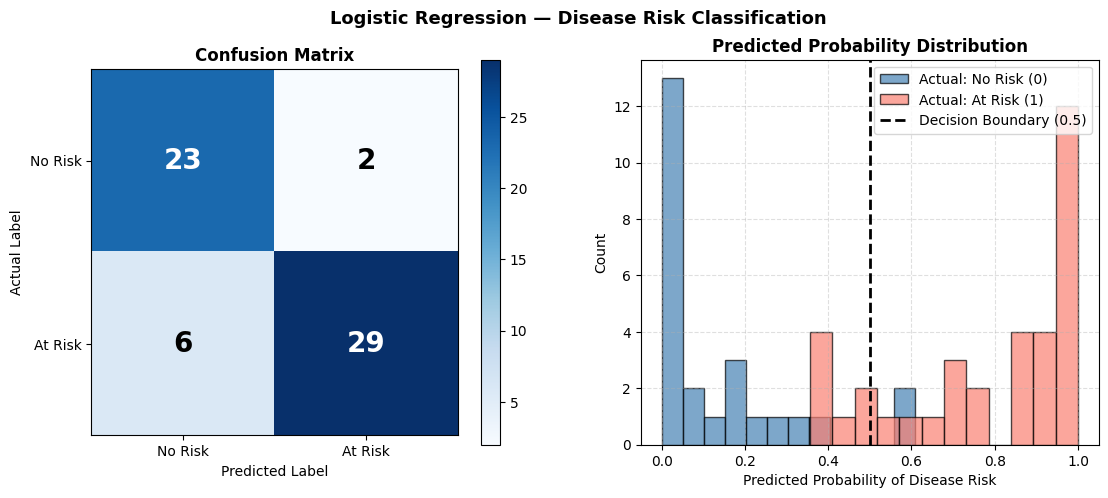

In [29]:

# PLOT 1 : Confusion Matrix Heatmap
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Logistic Regression — Disease Risk Classification',
             fontsize=13, fontweight='bold')

# Heatmap
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xticks([0, 1]);  axes[0].set_xticklabels(['No Risk', 'At Risk'])
axes[0].set_yticks([0, 1]);  axes[0].set_yticklabels(['No Risk', 'At Risk'])
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('Actual Label')

for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(cm[i, j]),
                     ha='center', va='center',
                     fontsize=20, fontweight='bold',
                     color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.colorbar(im, ax=axes[0])


# PLOT 2 : Predicted Probability Distribution
prob_no_risk = y_pred_prob[y_test == 0]
prob_at_risk = y_pred_prob[y_test == 1]
axes[1].hist(prob_no_risk, bins=12, alpha=0.7, color='steelblue',edgecolor='black', label='Actual: No Risk (0)')
axes[1].hist(prob_at_risk, bins=12, alpha=0.7, color='salmon',edgecolor='black', label='Actual: At Risk (1)')
axes[1].axvline(0.5, color='black', linestyle='--', linewidth=2,label='Decision Boundary (0.5)')
axes[1].set_title('Predicted Probability Distribution', fontweight='bold')
axes[1].set_xlabel('Predicted Probability of Disease Risk')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.4)
plt.show()

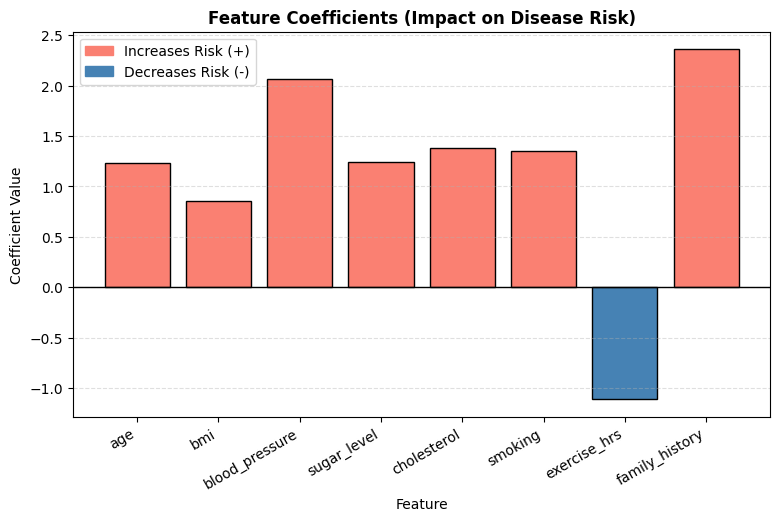

In [22]:
# PLOT 3 : Feature Coefficients Bar Chart

coefs = model.coef_[0]
colors = ['salmon' if c > 0 else 'steelblue' for c in coefs]

plt.figure(figsize=(9, 5))
bars = plt.bar(features, coefs, color=colors, edgecolor='black')
plt.axhline(0, color='black', linewidth=1)
plt.title('Feature Coefficients (Impact on Disease Risk)',fontsize=12, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=30, ha='right')

red_patch  = mpatches.Patch(color='salmon',    label='Increases Risk (+)')
blue_patch = mpatches.Patch(color='steelblue', label='Decreases Risk (-)')
plt.legend(handles=[red_patch, blue_patch])
plt.grid(axis='y', linestyle='--', alpha=0.4)

In [30]:
# (vi)  PREDICT CLASS LABEL FOR NEW DATA POINTS

print(" Predict Disease Risk for New Patient")

print("  (smoking & family_history: 0=No, 1=Yes)\n")

try:
    age_v  = float(input("  Age                  : "))
    bmi_v  = float(input("  BMI                  : "))
    bp_v   = float(input("  Blood Pressure       : "))
    sug_v  = float(input("  Sugar Level          : "))
    chol_v = float(input("  Cholesterol          : "))
    smk_v  = float(input("  Smoking (0/1)        : "))
    exc_v  = float(input("  Exercise Hrs/week    : "))
    fam_v  = float(input("  Family History (0/1) : "))

    new_patient = pd.DataFrame([[age_v, bmi_v, bp_v, sug_v, chol_v, smk_v, exc_v, fam_v]],columns=features)
    new_scaled  = scaler.transform(new_patient)
    prediction  = model.predict(new_scaled)[0]
    probability = model.predict_proba(new_scaled)[0]

    print(f"\n   Predicted Class     : {' AT RISK (1)' if prediction == 1 else ' NO RISK (0)'}")
    print(f"  Probability No Risk  : {probability[0]*100:.2f}%")
    print(f"  Probability At Risk  : {probability[1]*100:.2f}%")

except Exception:
    # Non-interactive fallback
    samples = [
        [65, 32.5, 160, 180, 270, 1, 1.0, 1],   # high risk
        [25, 22.0,  90,  80, 160, 0, 8.0, 0],   # low risk
    ]
    print("  (Non-interactive mode — using sample patients)\n")
    for s in samples:
        new_p  = pd.DataFrame([s], columns=features)
        ns     = scaler.transform(new_p)
        pred   = model.predict(ns)[0]
        prob   = model.predict_proba(ns)[0]
        print(f"  Input   : {dict(zip(features, s))}")
        print(f"  Result  : {' AT RISK (1)' if pred == 1 else ' NO RISK (0)'}"
              f"  |  No Risk: {prob[0]*100:.1f}%  At Risk: {prob[1]*100:.1f}%\n")

 Predict Disease Risk for New Patient
  (smoking & family_history: 0=No, 1=Yes)



  Age                  :  25
  BMI                  :  36.8
  Blood Pressure       :  143
  Sugar Level          :  126
  Cholesterol          :  160
  Smoking (0/1)        :  1
  Exercise Hrs/week    :  1.2
  Family History (0/1) :  0



   Predicted Class     :  NO RISK (0)
  Probability No Risk  : 81.96%
  Probability At Risk  : 18.04%
